## Project Description
This project analyzes a simulated student performance dataset that combines academic, behavioral, lifestyle, psychological, and digital factors. The goal is to understand how study habits, well-being, and technology usage influence student productivity and academic outcomes. The dataset reflects realistic educational scenarios, making it suitable for data analysis and machine learning applications.

#### Objectives

*   Explore the factors that influence student productivity and academic performance.
*   Identify behavioral and lifestyle patterns associated with different performance levels.
*   Analyze the impact of study habits, sleep, stress, motivation, and digital activities on learning outcomes.
*   Build predictive models to estimate exam scores and classify student performance.
*   Demonstrate skills in data cleaning, exploratory data analysis (EDA), visualization, and fundamental machine learning techniques.

#### Key Targets


*   Final Exam Score: Numerical prediction of academic performance.
*   Performance Category: Classification of students into High, Medium, or Low performance groups.

#### Skills Demonstrated


*   Data Cleaning & Preparation
*   Exploratory Data Analysis (EDA)
*   Data Visualization
*   Feature Analysis & Correlation
*   Regression & Classification Models
*   Machine Learning Fundamentals
*   Data-Driven Insights & Communication

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Description of the Variables in the "Student Academic Performance Prediction" Dataset

**Data Source:** https://www.kaggle.com/datasets/aiexplorer77/academic-performance-prediction?select=student_performance_dataset.csv

**Description:** This dataset contains information related to student academic performance, including personal factors, study habits, lifestyle behaviors, psychological characteristics, and social conditions. It is designed to analyze the factors that influence student productivity and educational outcomes.

| Variable | Descripción | Tipo |
|---|---|---|
| `student_id` | Identificador único del estudiante | Numérica |
| `age` | Edad del estudiante | Numérica |
| `gender` | Género del estudiante | Categórica |
| `city_type` | Tipo de ciudad de residencia | Categórica |
| `study_hours_per_day` | Horas de estudio diarias | Numérica |
| `deep_work_sessions` | Número de sesiones de estudio profundo | Numérica |
| `assignment_completion_rate` | Porcentaje de tareas completadas | Numérica |
| `attendance_percentage` | Porcentaje de asistencia | Numérica |
| `social_media_hours` | Horas dedicadas a redes sociales | Numérica |
| `doomscrolling_before_sleep` | Uso de redes antes de dormir (nivel/frecuencia) | Numérica |
| `notification_distractions` | Número de distracciones por notificaciones | Numérica |
| `ai_tool_usage_hours` | Horas de uso de herramientas de IA | Numérica |
| `gaming_hours` | Horas dedicadas a videojuegos | Numérica |
| `stress_level` | Nivel de estrés | Numérica |
| `motivation_level` | Nivel de motivación | Numérica |
| `focus_score` | Nivel de concentración | Numérica |
| `procrastination_index` | Índice de procrastinación | Numérica |
| `mental_state` | Estado mental del estudiante | Categórica |
| `sleep_hours` | Horas de sueño | Numérica |
| `caffeine_intake` | Consumo de cafeína | Numérica |
| `physical_activity_hours` | Horas de actividad física | Numérica |
| `internet_quality` | Calidad del internet | Numérica |
| `family_support` | Nivel de apoyo familiar | Numérica |
| `financial_stress` | Nivel de estrés financiero | Numérica |
| `learning_style` | Estilo de aprendizaje | Categórica |
| `career_goal` | Objetivo profesional | Categórica |
| `productivity_after_midnight` | Productividad después de medianoche | Numérica |
| `revision_efficiency` | Eficiencia de repaso | Numérica |
| `burnout_risk` | Riesgo de agotamiento académico | Numérica |
| `consistency_score` | Nivel de consistencia en hábitos | Numérica |
| `final_exam_score` | Puntaje del examen final | Numérica |
| `performance_category` | Categoría de desempeño académico (ej. alto, medio, bajo) | Variable objetivo |

In [ ]:
#Cargue del dataset y visualisación preliminar
url = "student_performance_dataset.csv"
df = pd.read_csv(url)

print("Dataset cargado. Dimensiones:", df.shape)
print("\nPrimeras filas:")
df.head()

Dataset cargado. Dimensiones: (3000, 32)

Primeras filas:


,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High



## Loading the Dataset

In this section, the dataset structure will be examined to better understand its composition and available features. Data types will be reviewed, and a data quality assessment will be performed to identify missing values or inconsistencies.

These preliminary checks are essential to ensure the dataset is reliable and properly prepared for exploratory data analysis (EDA), visualization, and machine learni




In [ ]:
# EXPLORACIÓN DE DATOS
# Objetivo: entender estructura, tipos y estadísticas del dataset

# Información general: tipos de datos y valores no nulos
print("INFORMACIÓN DEL DATASET")
df.info()

# Estadísticas descriptivas: media, desviación, cuartiles
print("\nESTADÍSTICAS DESCRIPTIVAS")
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           3000 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,...,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,1499.50,19.03,3.99,3.51,69.93,74.56,2.95,0.49,61.96,1.54,...,3.50,1.05,5.55,5.47,5.56,5.55,5.45,5.54,5.51,54.80
std,866.17,2.55,1.50,2.30,17.56,14.47,1.50,0.50,33.13,0.93,...,2.27,0.73,2.91,2.86,2.87,2.86,2.89,2.84,2.86,18.69
min,0.00,15.00,0.50,0.00,40.00,50.00,0.00,0.00,5.00,0.00,...,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00
25%,749.75,17.00,2.90,1.00,55.00,62.00,1.90,0.00,32.00,0.90,...,2.00,0.50,3.00,3.00,3.00,3.00,3.00,3.00,3.00,42.00
50%,1499.50,19.00,4.00,4.00,70.00,74.00,2.90,0.00,62.00,1.50,...,3.00,1.00,6.00,5.00,6.00,6.00,5.00,6.00,6.00,55.00
75%,2249.25,21.00,5.00,6.00,85.00,87.00,3.92,1.00,91.00,2.10,...,5.00,1.60,8.00,8.00,8.00,8.00,8.00,8.00,8.00,67.00
max,2999.00,23.00,8.80,7.00,100.00,100.00,8.90,1.00,119.00,5.00,...,7.00,3.90,10.00,10.00,10.00,10.00,10.00,10.00,10.00,100.00


In [ ]:
#Verificación de valores null
df.isnull().sum()

,0
student_id,0
age,0
gender,0
city_type,0
study_hours_per_day,0
deep_work_sessions,0
assignment_completion_rate,0
attendance_percentage,0
social_media_hours,60
doomscrolling_before_sleep,0


In [ ]:
#Longitud del dataset
df.shape

(3000, 32)

In [ ]:
df.nunique()

,0
student_id,3000
age,9
gender,2
city_type,3
study_hours_per_day,82
deep_work_sessions,8
assignment_completion_rate,61
attendance_percentage,51
social_media_hours,76
doomscrolling_before_sleep,2



### Key Findings

- **Total records:** 3,000
- **Total variables:** 32
- **Missing values:** 3 variables contain missing data, affecting a total of 60 records
- **Data types:**
  - `int64`: 19 variables
  - `float64`: 7 variables
  - `object`: 6 variables



##Limpieza de datos

In [ ]:

# Rellenar valores faltantes con la mediana
df['social_media_hours'] = df['social_media_hours'].fillna(df['social_media_hours'].median())
df['focus_score'] = df['focus_score'].fillna(df['focus_score'].median())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())


In [ ]:
# Verificación de valores null
df.isnull().sum()

,0
student_id,0
age,0
gender,0
city_type,0
study_hours_per_day,0
deep_work_sessions,0
assignment_completion_rate,0
attendance_percentage,0
social_media_hours,60
doomscrolling_before_sleep,0



## Analysis

The identified missing values were cleaned and verified, using the **median** to preserve the original distribution and avoid altering the dataset's b


## Exploratory Data Analysis (EDA)

The exploratory data analysis phase continues with the following objectives:

- Analyze the dataset structure and characteristics.
- Visualize patterns and trends within the data.
- Detect relationships between variables.
- Identify the most important features influencing student performance.











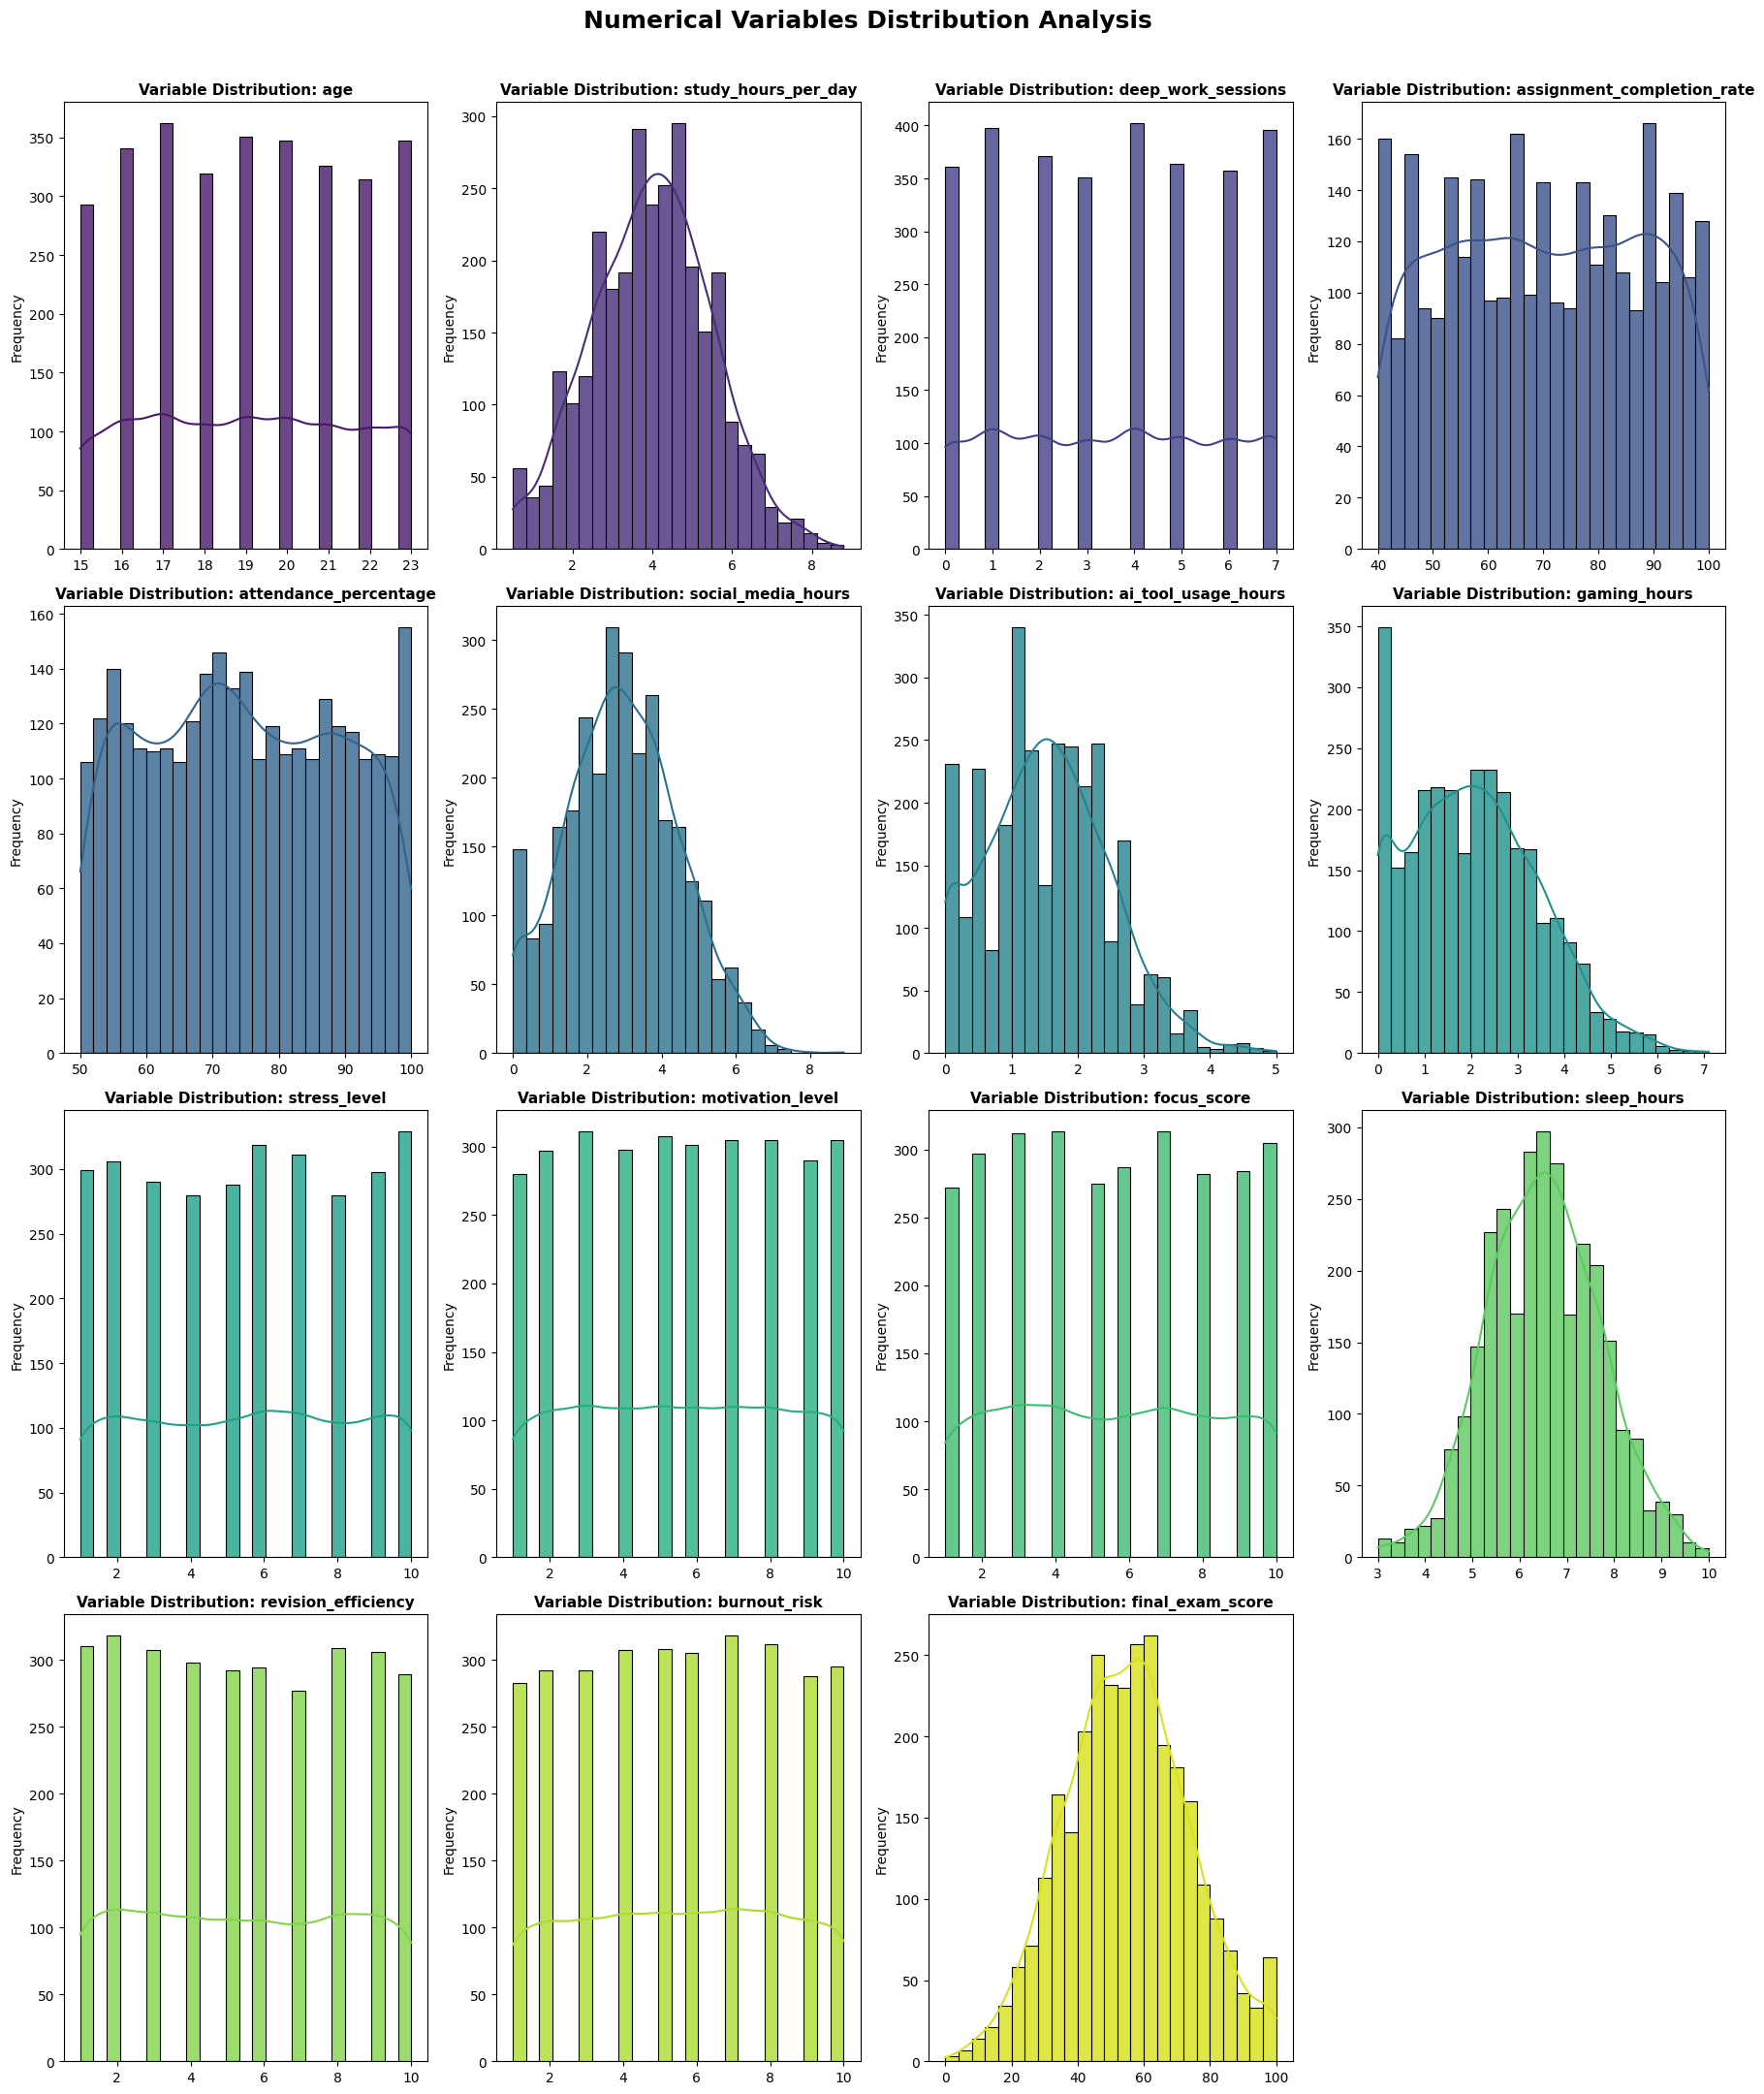

In [ ]:
#Distribución de variables numericas
numerical_cols = [
    'age',
    'study_hours_per_day',
    'deep_work_sessions',
    'assignment_completion_rate',
    'attendance_percentage',
    'social_media_hours',
    'ai_tool_usage_hours',
    'gaming_hours',
    'stress_level',
    'motivation_level',
    'focus_score',
    'sleep_hours',
    'revision_efficiency',
    'burnout_risk',
    'final_exam_score'
]


custom_palette = sns.color_palette("viridis", len(numerical_cols))

plt.figure(figsize=(18, 22))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)

    sns.histplot(
        df[col],
        kde=True,
        color=custom_palette[i],
        bins=25,
        edgecolor='black',
        alpha=0.8
    )

    plt.title(f'Variable Distribution: {col}', fontsize=11, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.suptitle('Numerical Variables Distribution Analysis', fontsize=18,
             fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Analysis

- The distributions show that most variables exhibit approximately normal behavior, such as study hours and final exam scores.
- Variables such as stress level and social media usage display moderate dispersion, indicating variability in students' habits and behaviors.
- Some variables present potential outliers that could influence predictive model performance.
- Overall, the analyzed features are suitable for statistical modeling, as they exhibit consistent and well-defined patterns.


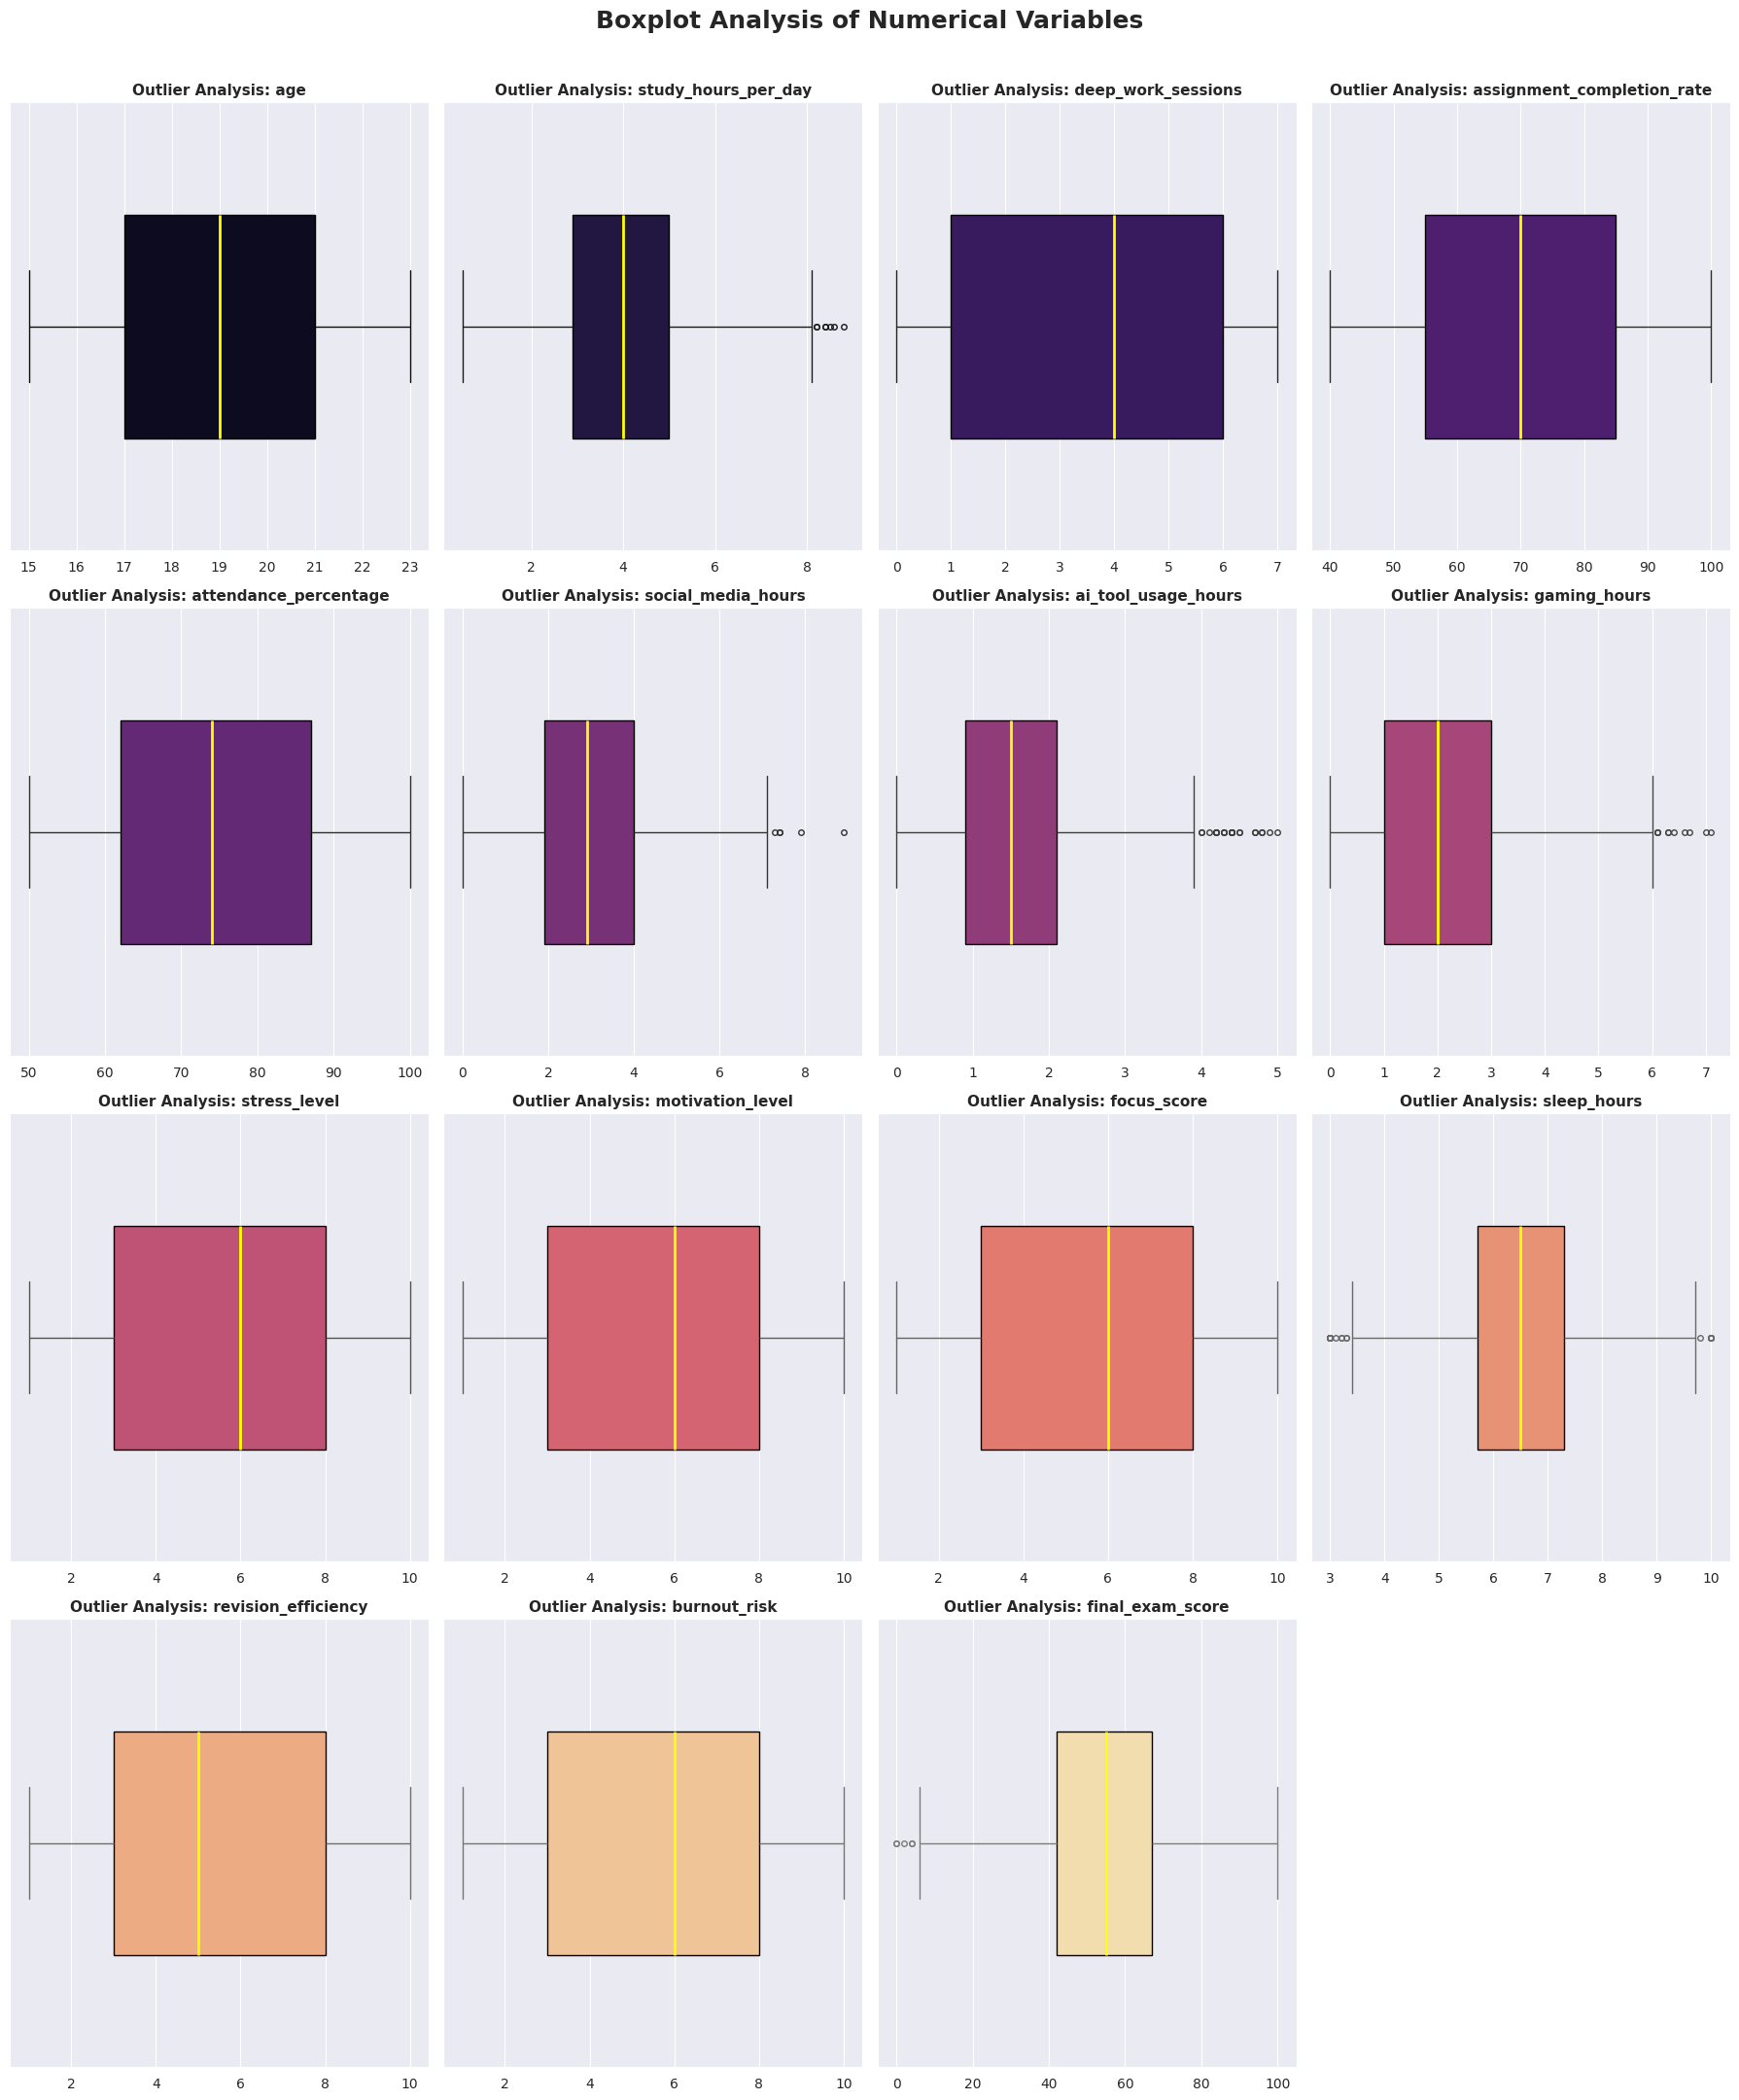

In [ ]:
# Detección de outliers

sns.set_style("darkgrid")

plt.figure(figsize=(18, 22))
palette_alt = sns.color_palette("magma", len(numerical_cols))


for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)

    sns.boxplot(
        x=df[col],
        color=palette_alt[i],
        width=0.5,
        fliersize=4,
        boxprops=dict(edgecolor='black'),
        medianprops=dict(color='yellow', linewidth=2)
    )

    plt.title(f'Outlier Analysis: {col}', fontsize=11, fontweight='bold')
    plt.xlabel('')

plt.suptitle('Boxplot Analysis of Numerical Variables', fontsize=18,
             fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Analysis

- The boxplots show that most variables have relatively symmetric distributions, although some contain outliers, particularly in features such as study hours and digital tool usage.
- Behavioral variables such as stress levels and social media usage exhibit noticeable variability, suggesting significant differences among students.
- The presence of outliers indicates potential extreme behaviors that may influence the performance of predictive models.
- Overall, the variables display a moderate level of dispersion, making them suitable for statistical analysis and modeling.

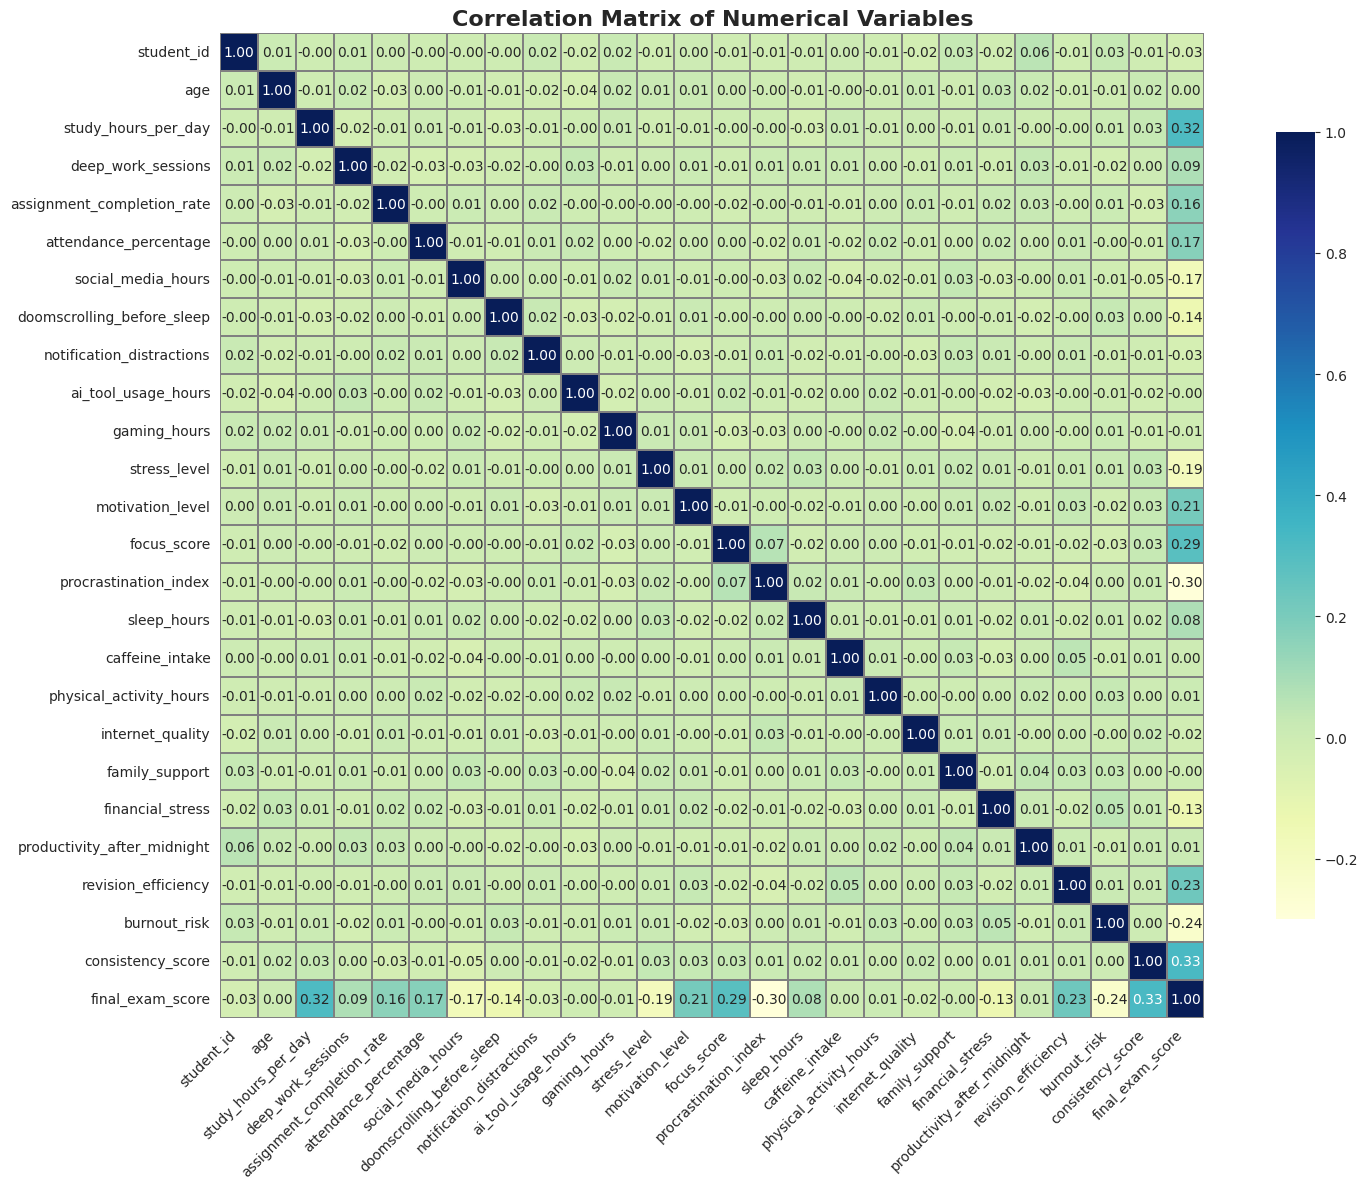

In [ ]:
#matriz de correlación
sns.set_style("white")
plt.figure(figsize=(16, 12))

corr_matrix = df.corr(numeric_only=True)


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={"shrink": 0.8},
    square=True
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=16,
          fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


## Analysis

- The heatmap shows that most variables have low correlations, indicating a high degree of independence among many factors in the dataset.
- Moderate positive relationships are observed between variables such as study hours and final exam score, as well as between focus and academic performance.
- Negative correlations are also identified between variables such as procrastination and stress versus performance, suggesting an adverse impact on academic outcomes.
- Overall, the analysis highlights the variables with the greatest influence on final exam scores, providing valuable insights for feature selection in predictive modeling.






Relación de variables con el puntaje final:

procrastination_index         -0.299475
burnout_risk                  -0.239082
stress_level                  -0.186721
social_media_hours            -0.172449
doomscrolling_before_sleep    -0.138240
financial_stress              -0.127100
notification_distractions     -0.031477
student_id                    -0.025445
internet_quality              -0.018411
gaming_hours                  -0.010042
family_support                -0.004131
ai_tool_usage_hours           -0.003776
age                            0.000172
caffeine_intake                0.000743
physical_activity_hours        0.008024
productivity_after_midnight    0.014107
sleep_hours                    0.082183
deep_work_sessions             0.086185
assignment_completion_rate     0.159037
attendance_percentage          0.172020
motivation_level               0.209093
revision_efficiency            0.230729
focus_score                    0.286838
study_hours_per_day            0.3

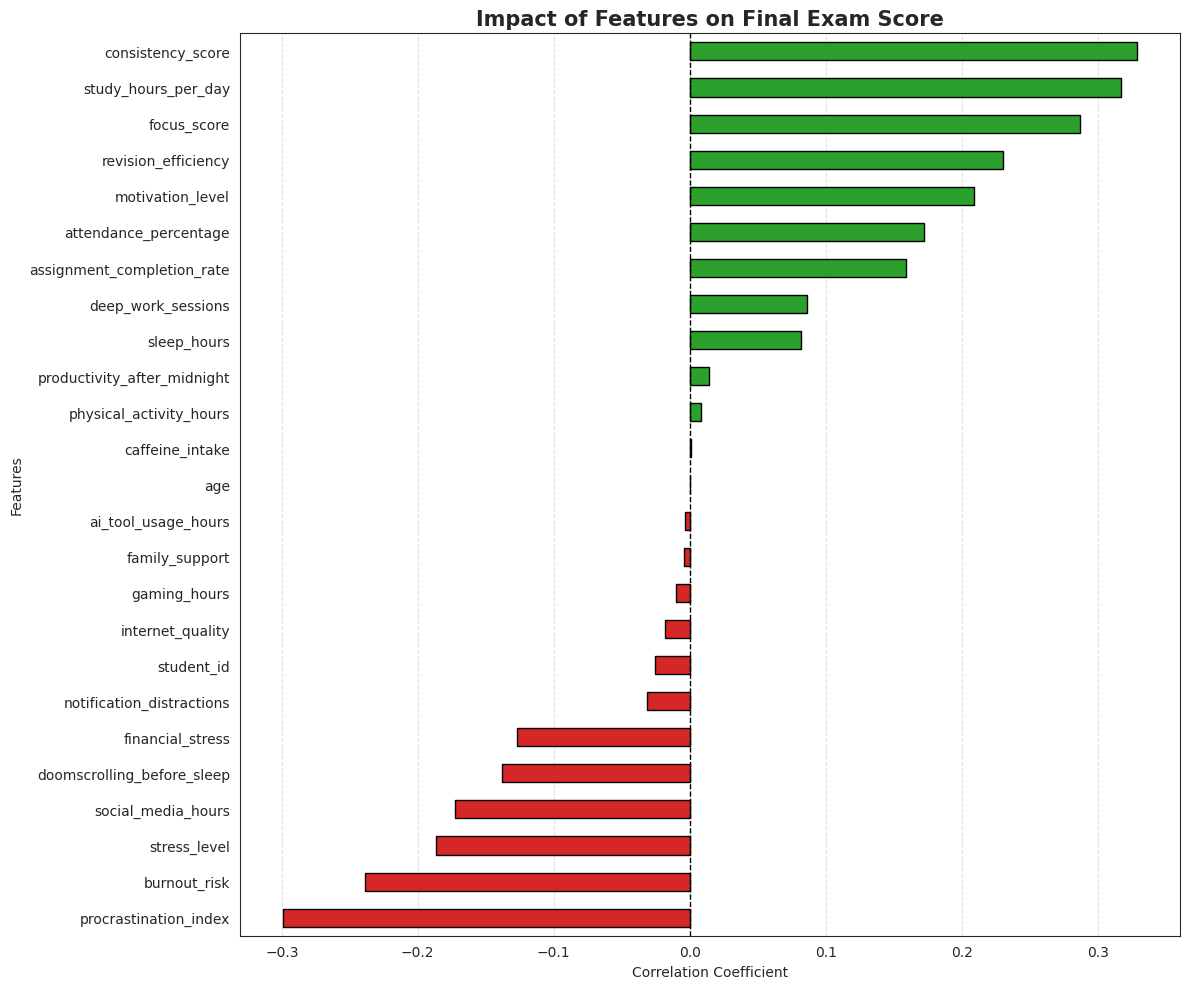

In [ ]:
#Identificación de variables mas relacionadas

target_corr = correlation['final_exam_score'].sort_values(ascending=True)

print("\nRelación de variables con el puntaje final:\n")
print(target_corr)

colors_dynamic = ['#d62728' if val < 0 else '#2ca02c' for val in target_corr]

plt.figure(figsize=(12, 10))

target_corr.drop('final_exam_score').plot(
    kind='barh',
    color=colors_dynamic[:-1],
    edgecolor='black'
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.title('Impact of Features on Final Exam Score', fontsize=15,
          fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Analysis

- The analysis shows that variables such as **consistency_score**, **study_hours_per_day**, and **focus_score** have the strongest positive correlations with the final exam score, indicating their significant influence on academic performance.
- In contrast, variables such as **procrastination_index**, **burnout_risk**, and **stress_level** exhibit negative correlations, suggesting a detrimental impact on academic outcomes.
- The results indicate that factors related to study habits, discipline, and focus have a greater influence on performance than external variables.
